In [ ]:
!pip install kaggle


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shrutibhargava94/india-air-quality-data")

print("Path to dataset files:", path)

100%|██████████| 5.22M/5.22M [00:00<00:00, 68.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shrutibhargava94/india-air-quality-data/versions/1


In [ ]:
print(df.columns)


Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')


/tmp/ipython-input-2096876786.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/data-3.csv",
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


Index(['STN_CODE', 'SAMPLING_DATE', 'STATE', 'LOCATION', 'AGENCY', 'TYPE',
       'SO2', 'NO2', 'RSPM', 'SPM', 'LOCATION_MONITORING_STATION', 'PM2_5',
       'DATE'],
      dtype='object')
ar = 0.1
br = 0.3


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]



Estimated Parameters:
Lambda (λ) = 0.0017973787074418161
Mu (μ) = 25.432490617577276
c = 0.023919101400240214


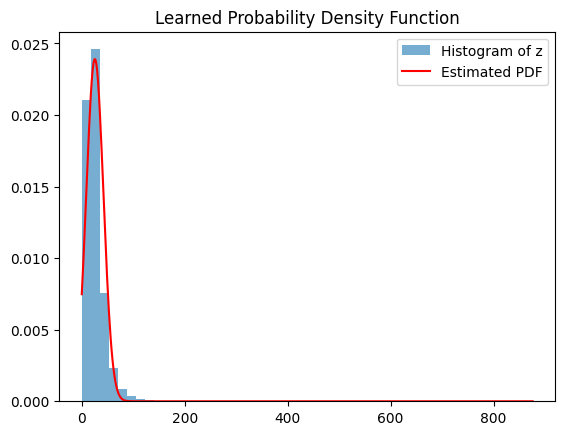

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize


# Load CSV file
df = pd.read_csv("/content/data-3.csv",
                 encoding='latin1',

                 encoding_errors='ignore')
df.columns = df.columns.str.strip()
df.columns = df.columns.str.upper()

print(df.columns)

# Use NO2 column and drop missing values
x = df['NO2'].dropna().values

r=102313045
# Compute ar and br
ar = 0.05 * (r % 7)
br = 0.3 * ((r % 5) + 1)

print("ar =", ar)
print("br =", br)

# =========================
# STEP 1: Transformation
# z = x + ar * sin(br * x)
# =========================

z = x + ar * np.sin(br * x)

# =========================
# STEP 2: Learn Parameters
# PDF: p(z) = c * exp(-λ (z - μ)^2)
# =========================

# Negative log likelihood function
def neg_log_likelihood(params):
    lam, mu = params

    # Avoid invalid lambda
    if lam <= 0:
        return np.inf

    # For Gaussian-type PDF
    c = np.sqrt(lam / np.pi)

    pdf = c * np.exp(-lam * (z - mu)**2)

    # Avoid log(0)
    pdf = np.clip(pdf, 1e-10, None)

    return -np.sum(np.log(pdf))

# Initial guess
initial_guess = [0.01, np.mean(z)]

# Minimize negative log likelihood
result = minimize(neg_log_likelihood, initial_guess)

lam_est, mu_est = result.x
c_est = np.sqrt(lam_est / np.pi)

# =========================
# STEP 3: Print Parameters
# =========================

print("\nEstimated Parameters:")
print("Lambda (λ) =", lam_est)
print("Mu (μ) =", mu_est)
print("c =", c_est)

# =========================
# Plot Learned PDF
# =========================

z_range = np.linspace(min(z), max(z), 500)
pdf_est = c_est * np.exp(-lam_est * (z_range - mu_est)**2)

plt.hist(z, bins=50, density=True, alpha=0.6, label="Histogram of z")
plt.plot(z_range, pdf_est, 'r', label="Estimated PDF")
plt.legend()
plt.title("Learned Probability Density Function")
plt.show()
